In [1]:
import torch.nn as nn
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Physical Parameters

lambda0 = 1.55 #micron
k0 = 2* np.pi / lambda0

n_core = 1.50
n_clad = 1.45
d = 2.0 #core width (micron)

x_min, x_max = -5.0, 5.0 #domain

In [17]:
#Dataset (collocation points)

N1 = 4000
N2 = 2000

# uniform
x1 = np.random.uniform(x_min, x_max, (N1,1))

# focused near interfaces
x2 = np.random.uniform(-1.5, 1.5, (N2,1))

x_train = np.vstack([x1, x2])
x_train = torch.tensor(x_train, dtype=torch.float32, requires_grad=True)

#Boundary
x_bc = torch.tensor([[x_min], [x_max]], dtype = torch.float32)

In [18]:
#  Index Profile

def refractive_index(x):
  n = torch.where(torch.abs(x) <=d/2,
                  torch.tensor(n_core),
                  torch.tensor(n_clad))
  return n

In [35]:
# Network

class PINN(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(1, 50),
        nn.Tanh(),
        nn.Linear(50, 50),
        nn.Tanh(),
        nn.Linear(50, 50),
        nn.Tanh(),
        nn.Linear(50,1)
    )

    # Beta -> trainable
    self.beta = nn.Parameter(torch.tensor([k0*1.48]))

  def forward(self,x):
    return self.net(x)

model = PINN()

In [36]:
#Optimizer

opt = torch.optim.Adam(model.parameters(),lr=1e-3)

# remaining loss weights
lambda_bc = 10.0
lambda_norm = 1.0

In [37]:
#Training loop

epochs = 10000
loss_hist=[]

for ep in range(epochs):
  opt.zero_grad()

  #Field prediction
  E = model(x_train)

  #First deriv
  dE_dx = torch.autograd.grad(E, x_train, grad_outputs=torch.ones_like(E), create_graph=True)[0]

  #Second deriv
  d2E_dx2 = torch.autograd.grad(dE_dx, x_train, grad_outputs = torch.ones_like(dE_dx), create_graph=True)[0]

  # RI
  n = refractive_index(x_train)

  #Residual
  residual = d2E_dx2 + (k0**2) * (n**2)*E - (model.beta**2)*E
  loss_phys = torch.mean(residual**2)

  #Boundary loss
  E_bc = model(x_bc)
  loss_bc = torch.mean(E_bc**2)

  #Norm loss
  loss_norm = (torch.mean(E**2) -  1.0)**2

  loss = 2*loss_phys + lambda_bc*loss_bc + lambda_norm*loss_norm

  loss.backward()
  opt.step()

  loss_hist.append(loss.item())

  if ep % 500 == 0:
    print(f"Epoch {ep}, Loss: {loss.item():.6e}")


print('Effective index: ', model.beta.item()/k0)


Epoch 0, Loss: 1.822089e+00
Epoch 500, Loss: 4.848349e-02
Epoch 1000, Loss: 3.223047e-02
Epoch 1500, Loss: 2.350565e-02
Epoch 2000, Loss: 1.944055e-02
Epoch 2500, Loss: 1.650037e-02
Epoch 3000, Loss: 1.439874e-02
Epoch 3500, Loss: 1.290631e-02
Epoch 4000, Loss: 1.156690e-02
Epoch 4500, Loss: 1.089812e-02
Epoch 5000, Loss: 1.130786e-02
Epoch 5500, Loss: 9.401659e-03
Epoch 6000, Loss: 9.273265e-03
Epoch 6500, Loss: 8.334295e-03
Epoch 7000, Loss: 8.161246e-03
Epoch 7500, Loss: 7.769039e-03
Epoch 8000, Loss: 7.366496e-03
Epoch 8500, Loss: 7.177408e-03
Epoch 9000, Loss: 7.124633e-03
Epoch 9500, Loss: 6.843043e-03
Effective index:  1.482330907746361


In [38]:
#Eval

x_test = np.linspace(x_min, x_max, 500).reshape(-1,1)
x_test_t = torch.tensor(x_test, dtype = torch.float32)

E_pred = model(x_test_t)
E_pred = E_pred.detach().numpy()

In [39]:
V = k0 * (d/2) * np.sqrt(n_core**2 - n_clad**2)
print("V number:", V)

V number: 1.5568407130746127


In [40]:
n_eff_approx = np.sqrt((n_core**2 + n_clad**2)/2)
print("Approx analytical n_eff:", n_eff_approx)
print("PINN n_eff:", model.beta.item()/k0)

Approx analytical n_eff: 1.475211849193193
PINN n_eff: 1.482330907746361


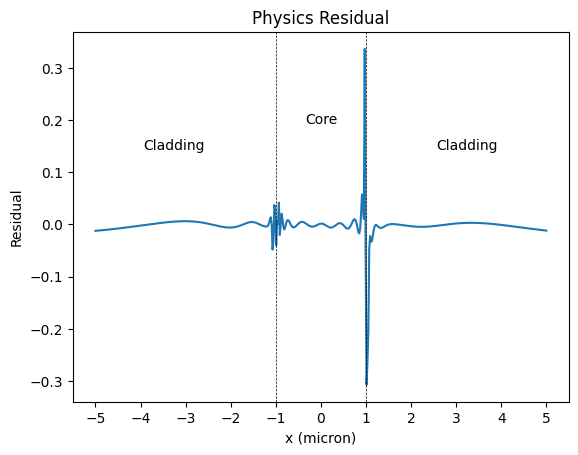

In [69]:
x_test_t.requires_grad_(True)
E = model(x_test_t)

dE_dx = torch.autograd.grad(E, x_test_t,
                            grad_outputs=torch.ones_like(E),
                            create_graph=True)[0]

d2E_dx2 = torch.autograd.grad(dE_dx, x_test_t,
                              grad_outputs=torch.ones_like(dE_dx),
                              create_graph=True)[0]

n = refractive_index(x_test_t)
residual = d2E_dx2 + (k0**2)*(n**2)*E - (model.beta**2)*E

residual_np = residual.detach().numpy()

plt.figure()
plt.plot(x_test, residual_np)
plt.title("Physics Residual")
plt.xlabel("x (micron)")
plt.ylabel("Residual")
plt.axvline(-1, linestyle='--', color='black', linewidth=0.5)
plt.axvline(1, linestyle='--', color='black', linewidth=0.5)
plt.text(0, 0.2, 'Core', ha='center', va='center')
plt.text(-3.25, 0.15, 'Cladding',ha='center', va='center')
plt.text(3.25, 0.15, 'Cladding', ha='center', va='center')

plt.xticks(np.arange(-5,6,1))

plt.grid(False)
plt.savefig("residual_plot.png", dpi=300)
plt.show()

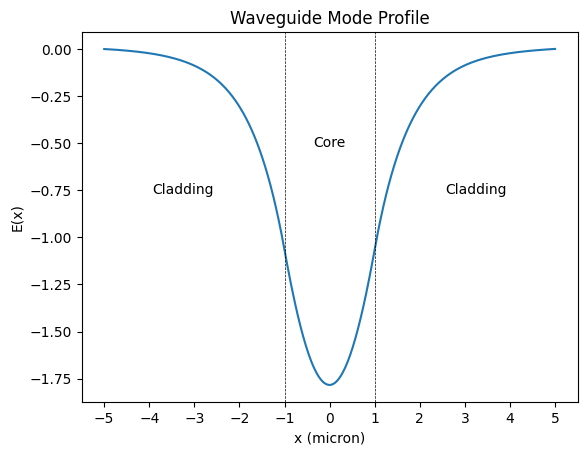

In [72]:
plt.figure()
plt.plot(x_test, E_pred)
plt.xlabel('x (micron)')
plt.ylabel('E(x)')
# Core region
plt.axvline(-1, linestyle='--', color='black', linewidth=0.5)
plt.axvline(1, linestyle='--', color='black', linewidth=0.5)
plt.text(0, -.5, 'Core', ha='center', va='center')
plt.text(-3.25, -0.75, 'Cladding',ha='center', va='center')
plt.text(3.25, -0.75, 'Cladding', ha='center', va='center')

plt.xticks(np.arange(-5,6,1))

plt.title('Waveguide Mode Profile')
plt.grid(False)
plt.savefig('field_plot.png', dpi=300)
plt.show()



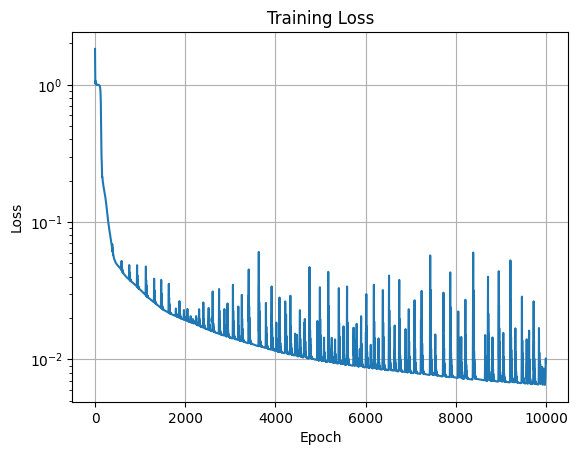

In [43]:
plt.figure()
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.yscale('log')
plt.grid()
plt.savefig('loss_plot.png', dpi=300)
plt.show()